# Colour Spaces: BGR, RGB, Grayscale and HSV, Split and Merge

This notebook explains the **colour spaces** a computer vision pipeline works with and how to switch between them with OpenCV. Choosing the right colour space is often the difference between a lane or object mask that works in sunlight *and* in shadow and one that fails as soon as the lighting changes.

**What it does:**
1. Explains the **HSV** colour space with generated pictures: the hue wheel, the saturation/value square and why hue stays stable when the light changes.
2. Loads the sample image `Self_Driving_Car.jpg` and prints its dimensions.
3. Shows why OpenCV's **BGR** order makes colours look wrong in matplotlib and how to fix it.
4. Inspects single pixels in BGR, RGB, HSV and grayscale.
5. Converts the image to **grayscale** and checks OpenCV's weighting formula by hand.
6. Converts the image to **HSV**, shows each channel and uses HSV to **select colours** (red, yellow, green and blue).
7. **Splits** the image into its B, G and R channels, shows them in grayscale and in colour, and **merges** them back.
8. Boosts the green channel and shows the **uint8 overflow trap** of plain `+` together with the correct saturating version.
9. Saves the results and ends with a conclusion.

**How it is implemented:**
- All images are shown inline with **matplotlib**, converted to RGB first. `cv2.imshow` / `cv2.waitKey` are not used, because they open separate windows, which don't work in Jupyter, Colab, VS Code or on a server without a display.
- File paths use `pathlib`, and a missing image raises a clear error instead of failing later with `None`.
- Tasks that have several possible solutions (displaying images, looking at pixels, selecting colours, showing channels, boosting a channel) are **reusable functions** with type hints and docstrings.
- `G + 100` on a `uint8` image **wraps around** (250 + 100 = 94). The notebook uses the saturating `cv2.add` and shows the difference.
- All settings are named constants in the configuration cell.

## 1. Imports

- `cv2` (OpenCV): image I/O and colour conversion
- `matplotlib`: displaying images and plots
- `numpy`: array operations
- `pathlib`: file paths that work on any OS

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

plt.rcParams["figure.dpi"] = 80  # keeps the saved notebook small

## 2. What is HSV?

A colour image is usually stored as **RGB**: three numbers that say how much **red**, **green** and **blue** light to mix. That matches how screens and camera sensors work, but not how people describe colours. We say "a dark orange" or "a pale blue", not "R=200, G=90, B=10".

**HSV** describes a colour in exactly that way, with three different questions:

| Channel | Question | Range in OpenCV (8-bit) | Usual range |
|---|---|---|---|
| **H**ue | *Which* colour is it? (red, yellow, green, …) | 0 – 179 | 0° – 360° |
| **S**aturation | How *pure* or intense is it? (grey → vivid) | 0 – 255 | 0 – 100 % |
| **V**alue | How *bright* is it? (black → full brightness) | 0 – 255 | 0 – 100 % |

> ⚠️ **OpenCV stores hue as degrees ÷ 2**, because 360 doesn't fit into a `uint8` (max 255). So red is at 0, yellow at 30, green at 60, cyan at 90, blue at 120 and magenta at 150. Hue is **circular**: 179 is right next to 0, and both are red.

The pictures below are generated with OpenCV itself (`cv2.cvtColor(..., cv2.COLOR_HSV2RGB)`), so they show exactly the values OpenCV uses.

In [2]:
def hsv_to_rgb(hsv: np.ndarray) -> np.ndarray:
    """Convert an OpenCV HSV uint8 array (H 0-179, S and V 0-255) to RGB."""
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

### 2.1 Hue: the colour wheel

Hue is an **angle** on a colour wheel. Going around the wheel runs through all the pure colours. In the wheel below the **distance from the centre** is the saturation: grey in the middle, vivid colours at the edge. The value (brightness) is kept at maximum.

The bar underneath is the same hue axis unrolled, labelled with OpenCV's 0 – 179 values.

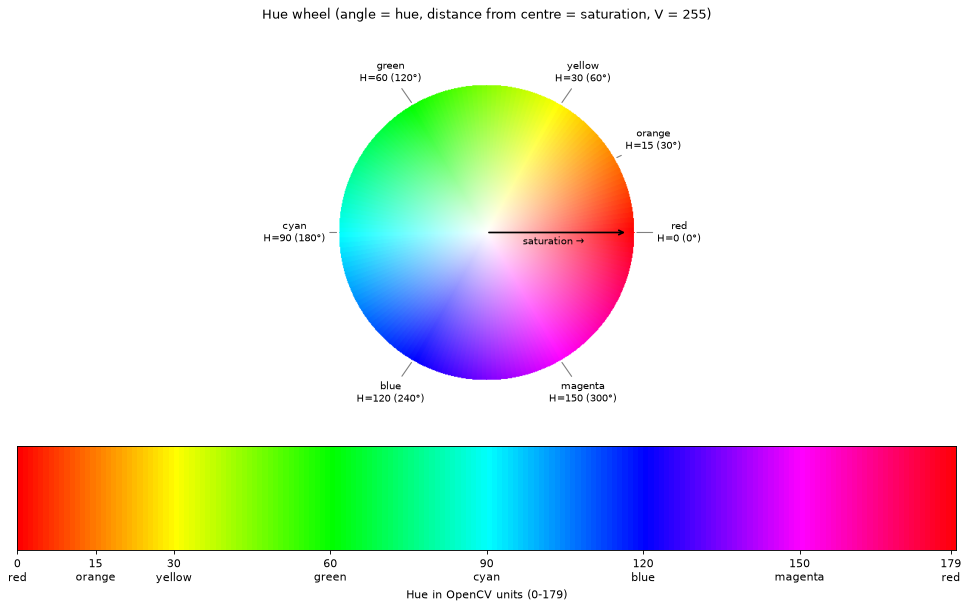

In [3]:
HUE_LANDMARKS = {0: "red", 15: "orange", 30: "yellow", 60: "green",
                 90: "cyan", 120: "blue", 150: "magenta", 179: "red"}

# Colour wheel: angle = hue, radius = saturation, value = 255
size = 401
yy, xx = np.mgrid[-1:1:size * 1j, -1:1:size * 1j]
radius = np.hypot(xx, yy)
angle_deg = (np.degrees(np.arctan2(-yy, xx)) + 360) % 360  # counter-clockwise, 0° = right

wheel_hsv = np.stack([angle_deg / 2, np.clip(radius, 0, 1) * 255, np.full_like(radius, 255)], axis=-1)
wheel_rgb = hsv_to_rgb(wheel_hsv)
wheel_rgb[radius > 1] = 255  # white background outside the circle

# Hue bar: H from 0 to 179, full saturation and value
hue_bar = hsv_to_rgb(np.stack(np.broadcast_arrays(
    np.arange(180)[np.newaxis, :], 255, 255), axis=-1).repeat(20, axis=0))

fig = plt.figure(figsize=(12, 7.5), layout="constrained")
ax_wheel, ax_bar = fig.subplots(2, 1, height_ratios=(4, 1))

ax_wheel.imshow(wheel_rgb, extent=(-1, 1, -1, 1))
for hue, name in HUE_LANDMARKS.items():
    if hue == 179:
        continue
    rad = np.radians(hue * 2)
    ax_wheel.annotate(f"{name}\nH={hue} ({hue * 2}°)", xy=(np.cos(rad), np.sin(rad)),
                      xytext=(1.3 * np.cos(rad), 1.25 * np.sin(rad)),
                      ha="center", va="center", fontsize=9,
                      arrowprops={"arrowstyle": "-", "color": "0.5"})
ax_wheel.annotate("", xy=(0.95, 0), xytext=(0, 0), arrowprops={"arrowstyle": "->", "lw": 1.5})
ax_wheel.text(0.45, -0.08, "saturation →", ha="center", fontsize=9)
ax_wheel.set_xlim(-1.6, 1.6)
ax_wheel.set_ylim(-1.4, 1.4)
ax_wheel.set_title("Hue wheel (angle = hue, distance from centre = saturation, V = 255)")
ax_wheel.axis("off")

ax_bar.imshow(hue_bar, aspect="auto", extent=(0, 180, 0, 1))
ax_bar.set_xticks(list(HUE_LANDMARKS), [f"{h}\n{n}" for h, n in HUE_LANDMARKS.items()])
ax_bar.set_yticks([])
ax_bar.set_xlabel("Hue in OpenCV units (0-179)")

plt.show()

### 2.2 Saturation and value

For **one** fixed hue, saturation and value span a square:
- moving **right** (more saturation) goes from grey to the pure colour
- moving **up** (more value) goes from black to full brightness

Every square has black along the bottom and greys along the left edge, **whatever the hue**. This is why hue on its own is meaningless for very dark or very grey pixels: when S or V is close to 0, the pixel has hardly any colour left.

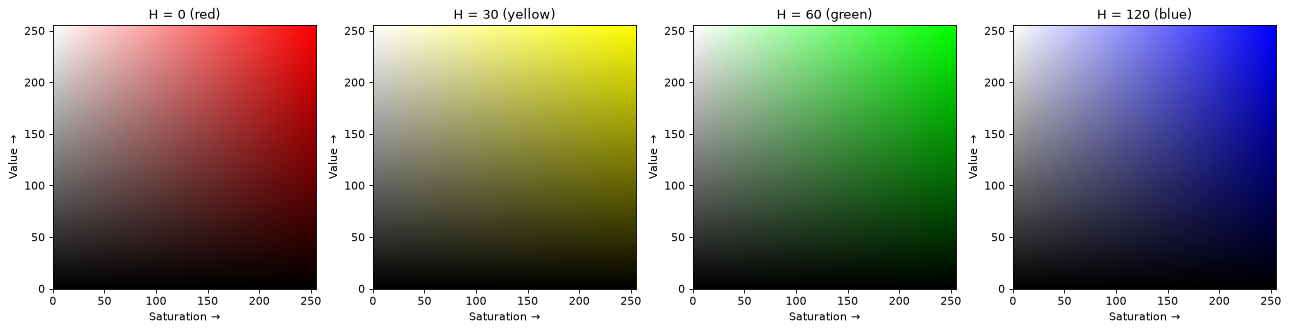

In [4]:
def sv_square(hue: int, size: int = 256) -> np.ndarray:
    """Return an RGB image of all saturation (x) and value (y, bottom = 0) combinations for one hue."""
    s, v = np.meshgrid(np.linspace(0, 255, size), np.linspace(255, 0, size))
    return hsv_to_rgb(np.stack([np.full_like(s, hue), s, v], axis=-1))


fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), layout="constrained")
for ax, hue in zip(axes, (0, 30, 60, 120)):
    ax.imshow(sv_square(hue), extent=(0, 255, 0, 255))
    ax.set_title(f"H = {hue} ({HUE_LANDMARKS[hue]})")
    ax.set_xlabel("Saturation →")
    ax.set_ylabel("Value →")
plt.show()

### 2.3 Why HSV is useful: hue survives shadows

This is the main reason HSV is used in lane and object detection. Imagine a red car body, half in sunlight and half in shadow. The shadow makes **all three RGB numbers** smaller, so a rule like "R > 200" breaks. In HSV only the **value** changes, while the hue (and mostly the saturation) stays the same, so a rule like "hue close to red" keeps working.

Below, the same colour is shown at five brightness levels. Look at how much R, G and B change compared with H.

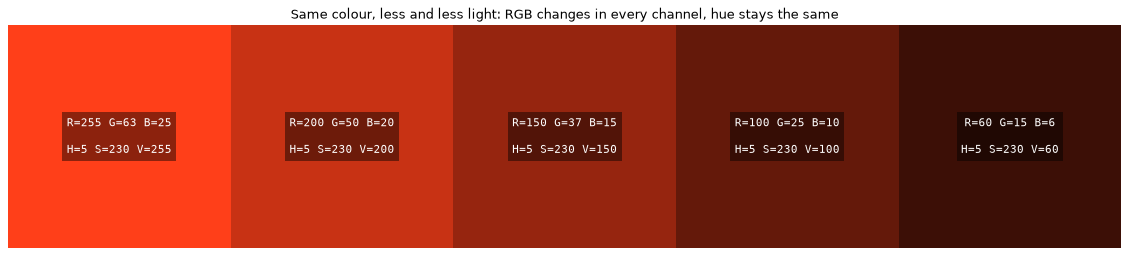

In [5]:
BASE_HSV = (5, 230, 255)  # a red-orange, like the car body in the sample image
brightness = (255, 200, 150, 100, 60)

patches_hsv = np.array([[(BASE_HSV[0], BASE_HSV[1], v) for v in brightness]], dtype=np.uint8)
patches_rgb = hsv_to_rgb(patches_hsv)

fig, ax = plt.subplots(figsize=(14, 3.6), layout="constrained")
ax.imshow(patches_rgb, extent=(0, len(brightness), 0, 1))
for i, ((r, g, b), (h, s, v)) in enumerate(zip(patches_rgb[0], patches_hsv[0])):
    ax.text(i + 0.5, 0.5, f"R={r} G={g} B={b}\n\nH={h} S={s} V={v}",
            ha="center", va="center", fontsize=10, family="monospace",
            color="white", bbox={"facecolor": "black", "alpha": 0.45, "edgecolor": "none"})
ax.set_title("Same colour, less and less light: RGB changes in every channel, hue stays the same")
ax.axis("off")
plt.show()

**In short:**
- **RGB/BGR** mixes colour and brightness in every channel. It is what cameras and screens use.
- **Grayscale** keeps only brightness. It is simple and fast, but can't tell a yellow line from a white one of the same brightness.
- **HSV** separates *which colour* (H) from *how vivid* (S) and *how bright* (V). This makes colour selection much more robust to lighting.

## 3. Configuration

- `INPUT_PATH`: the sample image. Image source: <https://www.flickr.com/photos/162308592@N07/47133183871/>
- `PIXELS`: the `(row, column)` positions we inspect.
- `COLOR_RANGES`: the HSV ranges used for colour selection in section 7. Each colour is a list of `(lower, upper)` bounds, because red needs **two** ranges (it sits at both ends of the hue axis).
- `GREEN_BOOST`: how much is added to the green channel in section 9.
- All results are saved to `OUTPUT_DIR`.

In [6]:
INPUT_PATH = Path("Self_Driving_Car.jpg")
OUTPUT_DIR = Path("output")

# (row, column) = (y, x) positions to inspect. NumPy indexes images as [row, column].
PIXELS = {
    "through the car window": (230, 450),
    "white car door": (350, 180),
    "red-orange car body": (300, 470),
    "blue sky": (40, 560),
}

# HSV ranges in OpenCV units: H 0-179, S 0-255, V 0-255
HSVRange = tuple[tuple[int, int, int], tuple[int, int, int]]
COLOR_RANGES: dict[str, list[HSVRange]] = {
    "red": [((0, 150, 120), (10, 255, 255)), ((170, 150, 120), (179, 255, 255))],
    "yellow": [((20, 120, 150), (35, 255, 255))],
    "green": [((36, 60, 40), (85, 255, 255))],
    "blue": [((95, 60, 150), (125, 255, 255))],
}

GREEN_BOOST = 100  # added to the green channel in section 9

CHANNEL_NAMES_BGR = ("Blue", "Green", "Red")

## 4. Load the image

`load_image` wraps `cv2.imread`, which returns `None` instead of raising an error when a file is missing or can't be decoded.

The image array has the shape **(height, width, channels)**, so rows come first. This is easy to mix up with the usual "width × height" notation.

In [7]:
def load_image(path: Path) -> np.ndarray:
    """Load a colour image with OpenCV (BGR order) and raise a clear error if it fails."""
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path.resolve()}")
    return image


image_bgr = load_image(INPUT_PATH)

height, width, channels = image_bgr.shape
print(f"Shape:    {image_bgr.shape}  (height, width, channels)")
print(f"Height:   {height} px")
print(f"Width:    {width} px")
print(f"Channels: {channels}")
print(f"Dtype:    {image_bgr.dtype}  (values 0-255)")
print(f"Size:     {image_bgr.size:,} values = {image_bgr.nbytes / 1024:.0f} KiB")

Shape:    (426, 640, 3)  (height, width, channels)
Height:   426 px
Width:    640 px
Channels: 3
Dtype:    uint8  (values 0-255)
Size:     817,920 values = 799 KiB


## 5. BGR vs. RGB: showing the image correctly

OpenCV loads images in **BGR** order (blue first) for historical reasons. Matplotlib and almost every other library expect **RGB**. If you pass the BGR array straight to `plt.imshow`, red and blue are swapped: the red car turns blue and the blue sky turns orange.

There are two common ways to fix it, and both give the same result:
- `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`: explicit and readable
- `image[..., ::-1]`: reverses the channel axis with NumPy slicing (a view, no copy)

`show_images` is a small helper used in the rest of the notebook. It shows several images side by side, uses a gray colour map for single-channel images and hides the axes.

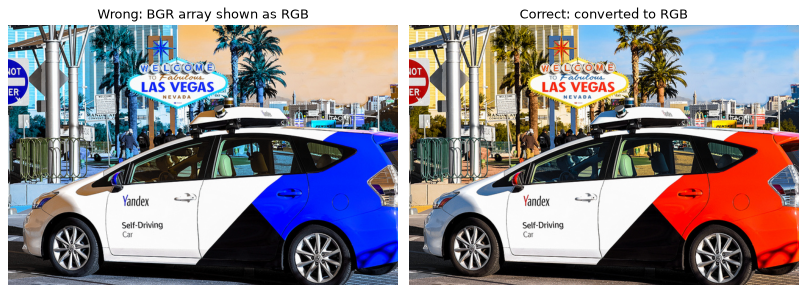

In [8]:
def show_images(
    images: dict[str, np.ndarray], cols: int | None = None, cmap: str = "gray",
    size: float = 5.0,
) -> None:
    """Show RGB or single-channel images side by side with their titles."""
    cols = cols or len(images)
    rows = -(-len(images) // cols)  # ceiling division
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * 0.7 * rows),
                             layout="constrained", squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (title, image) in zip(axes.flat, images.items()):
        ax.imshow(image, cmap=cmap if image.ndim == 2 else None, vmin=0, vmax=255)
        ax.set_title(title)
    plt.show()


image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
assert np.array_equal(image_rgb, image_bgr[..., ::-1]), "Both conversions should match"

show_images({
    "Wrong: BGR array shown as RGB": image_bgr,
    "Correct: converted to RGB": image_rgb,
})

> 💡 **Rule of thumb:** convert to RGB **once**, right after loading, if you want to display the image. Keep the BGR array for OpenCV functions that expect BGR (such as `cv2.imwrite`), and always name your variables after their colour space (`image_bgr`, `image_rgb`, `image_hsv`) so you never have to guess.

## 6. Inspect pixels and convert to grayscale

### 6.1 Single pixels in every colour space

A pixel is addressed as `image[row, column]`, i.e. `image[y, x]`. `describe_pixel` prints the same pixel in BGR, RGB, HSV and grayscale, so you can compare the colour spaces directly. The markers on the image show where the pixels are.

#  pixel                               (row, col)              BGR              RGB              HSV  Gray
1  through the car window              (230, 450)   (86, 136, 164)   (164, 136, 86)   (19, 121, 164)   139
2  white car door                      (350, 180)  (252, 252, 252)  (252, 252, 252)      (0, 0, 252)   252
3  red-orange car body                 (300, 470)     (2, 19, 254)     (254, 19, 2)    (2, 253, 254)    87
4  blue sky                             (40, 560)  (247, 197, 137)  (137, 197, 247)  (104, 114, 247)   185


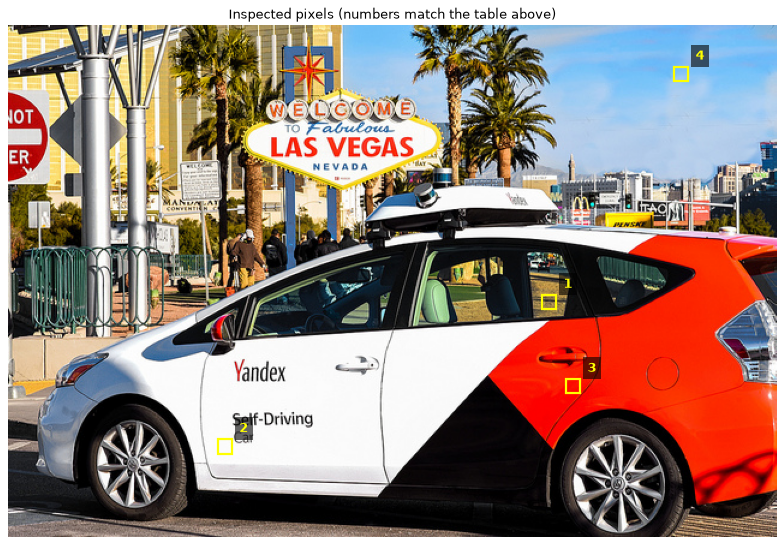

In [9]:
image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)


def describe_pixel(row: int, col: int) -> dict[str, tuple[int, ...]]:
    """Return the value of one pixel in BGR, RGB, HSV and grayscale."""
    return {
        "BGR": tuple(int(v) for v in image_bgr[row, col]),
        "RGB": tuple(int(v) for v in image_rgb[row, col]),
        "HSV": tuple(int(v) for v in image_hsv[row, col]),
        "Gray": (int(image_gray[row, col]),),
    }


print(f"{'#':2s} {'pixel':34s} {'(row, col)':>11s}  {'BGR':>15s}  {'RGB':>15s}  {'HSV':>15s}  {'Gray':>4s}")
for i, (name, (row, col)) in enumerate(PIXELS.items(), start=1):
    values = describe_pixel(row, col)
    print(f"{i:<2d} {name:34s} {str((row, col)):>11s}  {str(values['BGR']):>15s}  {str(values['RGB']):>15s}"
          f"  {str(values['HSV']):>15s}  {values['Gray'][0]:>4d}")

fig, ax = plt.subplots(figsize=(10, 6.7), layout="constrained")
ax.imshow(image_rgb)
for i, (name, (row, col)) in enumerate(PIXELS.items(), start=1):
    ax.add_patch(Rectangle((col - 6, row - 6), 12, 12, fill=False, edgecolor="yellow", linewidth=2))
    ax.annotate(str(i), xy=(col, row), xytext=(col + 12, row - 12), color="yellow",
                fontsize=12, fontweight="bold",
                bbox={"facecolor": "black", "alpha": 0.6, "edgecolor": "none"})
ax.set_title("Inspected pixels (numbers match the table above)")
ax.axis("off")
plt.show()

Things to notice:
- **BGR and RGB** contain the same three numbers, just in reverse order.
- The **red-orange car body** has a very low hue (close to 0 = red), and the **blue sky** has a hue of about 104 (≈ 208°, blue).
- The pixel **through the car window** is a light brown lawn, with a hue of 19 (orange/yellow).
- The **white car door** has a saturation close to 0: it has almost no colour, so its hue is meaningless.

### 6.2 Grayscale

`cv2.COLOR_BGR2GRAY` doesn't simply average the three channels. It uses the ITU-R BT.601 weights, which match how sensitive the human eye is to each colour. We see green as much brighter than blue:

$$\text{Gray} = 0.299\,R + 0.587\,G + 0.114\,B$$

The cell below checks this formula against OpenCV and compares it with a plain average. The grayscale image has **only one channel**, so its shape is `(height, width)` and it uses a third of the memory.

Colour shape: (426, 640, 3)  ->  grayscale shape: (426, 640)
Max difference between OpenCV and the BT.601 formula: 1 (rounding only)
Gray value at (350, 180): 252


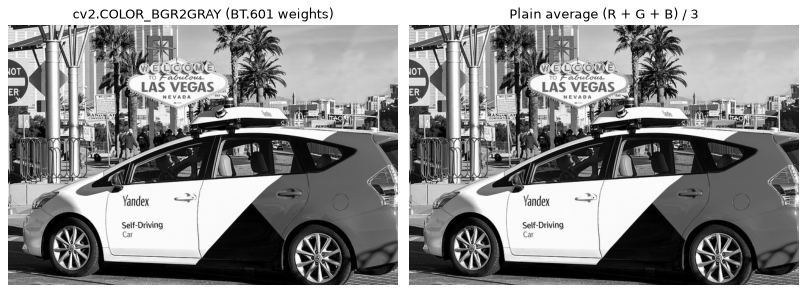

In [10]:
def to_gray_manual(image_rgb: np.ndarray, weights: tuple[float, float, float]) -> np.ndarray:
    """Convert RGB to grayscale with the given (R, G, B) weights."""
    gray = image_rgb.astype(np.float32) @ np.array(weights, dtype=np.float32)
    return np.clip(np.rint(gray), 0, 255).astype(np.uint8)


gray_bt601 = to_gray_manual(image_rgb, (0.299, 0.587, 0.114))
gray_mean = to_gray_manual(image_rgb, (1 / 3, 1 / 3, 1 / 3))

max_diff = int(np.abs(gray_bt601.astype(int) - image_gray.astype(int)).max())
print(f"Colour shape: {image_bgr.shape}  ->  grayscale shape: {image_gray.shape}")
print(f"Max difference between OpenCV and the BT.601 formula: {max_diff} (rounding only)")

row, col = PIXELS["white car door"]
print(f"Gray value at {(row, col)}: {image_gray[row, col]}")

show_images({
    "cv2.COLOR_BGR2GRAY (BT.601 weights)": image_gray,
    "Plain average (R + G + B) / 3": gray_mean,
})

The two versions look similar, but the plain average makes the red car body and the blue sky brighter than the eye perceives them, because it gives blue and red the same weight as green.

## 7. HSV

### 7.1 The HSV channels

If you display the HSV array directly as an image (for example with `cv2.imshow`), H, S and V are interpreted as if they were B, G and R. The result is a colourful but **meaningless** picture. The useful way to look at HSV is **one channel at a time**:

- **Hue** is shown with a circular `hsv` colour map, so each pixel is drawn in (roughly) its own colour. Areas with very low saturation (white car, grey road) have random-looking hue, because their hue has no meaning.
- **Saturation** is bright wherever the colour is vivid: the red car, the blue sky, the sign letters. White, grey and black areas are dark.
- **Value** is the brightness of the strongest channel, i.e. `max(R, G, B)`. It looks like a grayscale image, but pure colours such as the red car appear as bright as white.

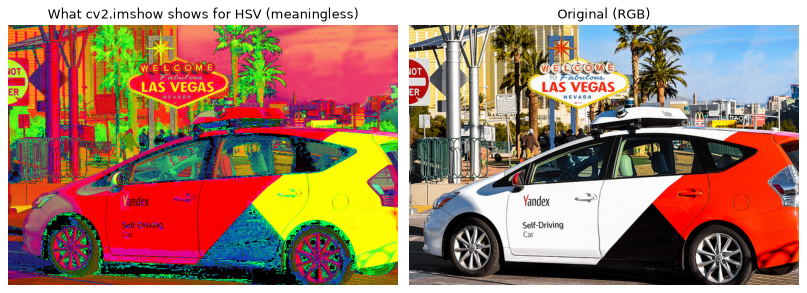

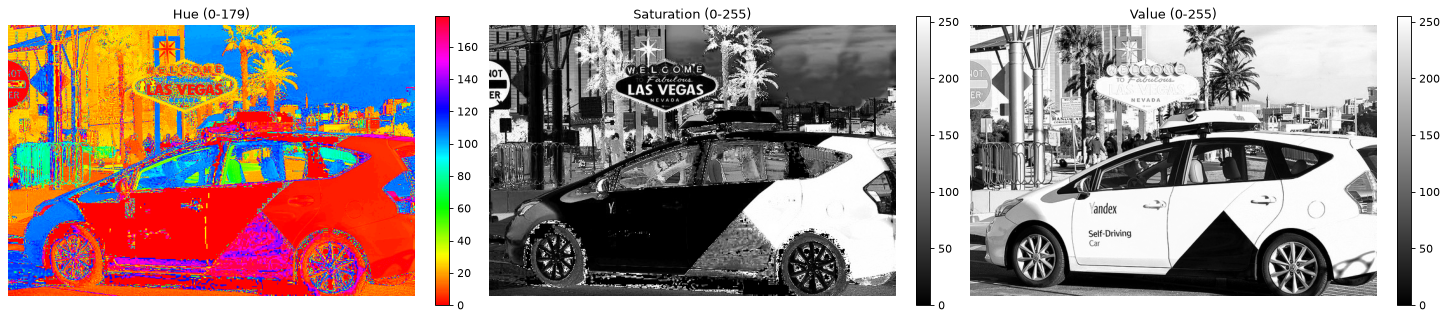

Value channel == max(B, G, R) for every pixel: True


In [11]:
def show_hsv_channels(image_hsv: np.ndarray) -> None:
    """Show the H, S and V channels of an OpenCV HSV image with suitable colour maps."""
    specs = (
        ("Hue (0-179)", 0, "hsv", 179),
        ("Saturation (0-255)", 1, "gray", 255),
        ("Value (0-255)", 2, "gray", 255),
    )
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.6), layout="constrained")
    for ax, (title, idx, cmap, vmax) in zip(axes, specs):
        im = ax.imshow(image_hsv[..., idx], cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, shrink=0.8)
    plt.show()


show_images({"What cv2.imshow shows for HSV (meaningless)": image_hsv[..., ::-1],
             "Original (RGB)": image_rgb})
show_hsv_channels(image_hsv)

value_is_max = np.array_equal(image_hsv[..., 2], image_bgr.max(axis=-1))
print(f"Value channel == max(B, G, R) for every pixel: {value_is_max}")

### 7.2 Selecting colours with HSV

This is what HSV is used for in practice. `cv2.inRange(image_hsv, lower, upper)` returns a binary mask that is 255 where **all three** channels are inside their range. A colour is defined mainly by a **hue** interval, while minimum **saturation** and **value** remove grey, white and dark pixels, whose hue is unreliable.

Because hue is circular, **red** lies at both ends of the axis (around 0 *and* around 179). `color_mask` therefore accepts a list of ranges and combines them with a bitwise OR. The same function works for any colour, for example for **yellow and white lane markings** in a road image.

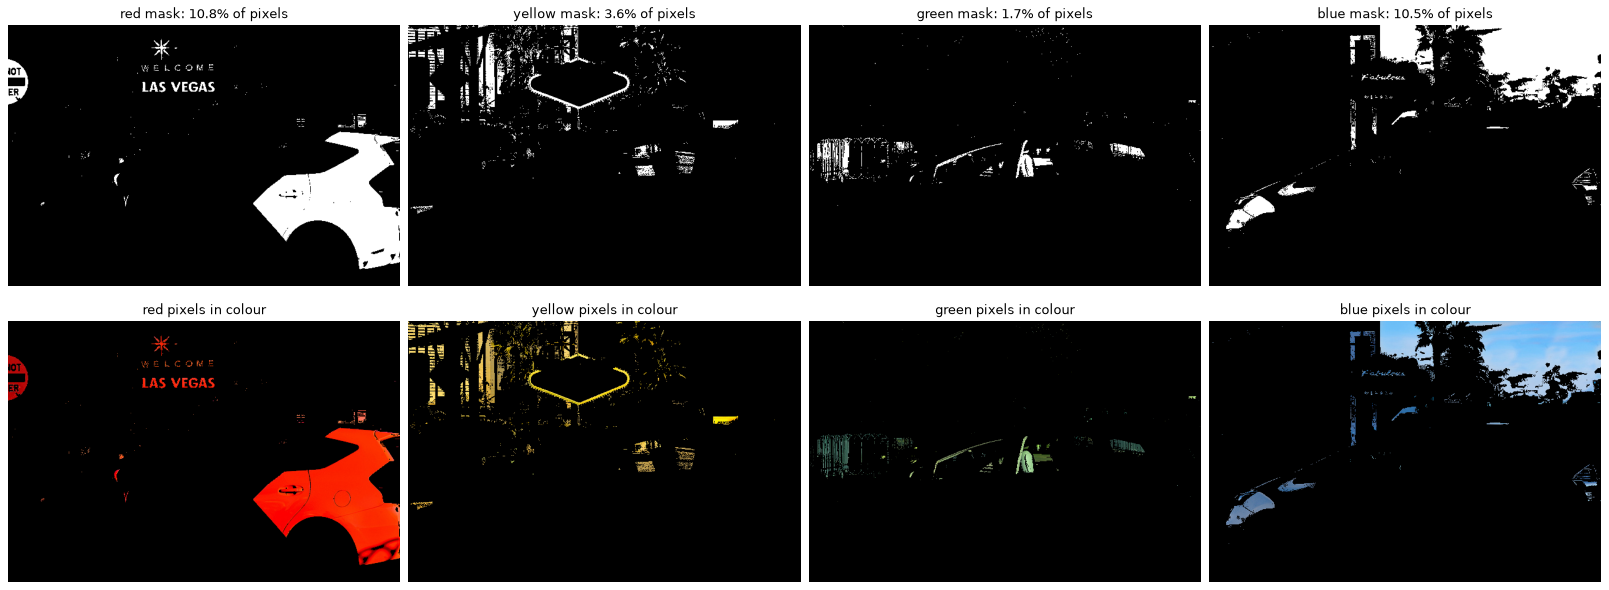

red     (0, 150, 120) - (10, 255, 255) OR (170, 150, 120) - (179, 255, 255)
yellow  (20, 120, 150) - (35, 255, 255)
green   (36, 60, 40) - (85, 255, 255)
blue    (95, 60, 150) - (125, 255, 255)


In [12]:
def color_mask(image_hsv: np.ndarray, ranges: list[HSVRange]) -> np.ndarray:
    """Return a uint8 mask (0 or 255) of the pixels inside any of the given HSV ranges."""
    mask = np.zeros(image_hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        mask |= cv2.inRange(image_hsv, np.array(lower), np.array(upper))
    return mask


def keep_masked(image_rgb: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Keep the pixels where mask is non-zero and set all others to black."""
    return cv2.bitwise_and(image_rgb, image_rgb, mask=mask)


color_masks = {name: color_mask(image_hsv, ranges) for name, ranges in COLOR_RANGES.items()}

fig, axes = plt.subplots(2, len(color_masks), figsize=(5 * len(color_masks), 7.4), layout="constrained")
for (ax_mask, ax_kept), (name, mask) in zip(axes.T, color_masks.items()):
    ax_mask.imshow(mask, cmap="gray")
    ax_mask.set_title(f"{name} mask: {np.count_nonzero(mask) / mask.size:.1%} of pixels")
    ax_kept.imshow(keep_masked(image_rgb, mask))
    ax_kept.set_title(f"{name} pixels in colour")
for ax in axes.flat:
    ax.axis("off")
plt.show()

for name, ranges in COLOR_RANGES.items():
    print(f"{name:7s} {' OR '.join(f'{lo} - {hi}' for lo, hi in ranges)}")

What the masks show for this image:
- **Red** finds the car body, the "LAS VEGAS" letters, the star on the sign and the stop sign on the left.
- **Yellow** finds the border of the sign and the yellow building facades.
- **Green** finds only a few pixels: the teal fence on the left and the seats and lawn seen through the car window. The **palm trees are not green in HSV terms**: in the bright sunlight their leaves are olive, with a hue of about 20 – 30, which is the *yellow* range. This is a good reminder to check the actual hue values instead of trusting what a colour "looks like".
- **Blue** finds the sky and the sky reflected on the car's bonnet and windows.
- The **white car**, the grey road and the black parts appear in **none** of the masks, because their saturation is too low. To select white (as for lane markings), you would use low saturation and high value instead of a hue range.

### 7.3 HSV vs. RGB for the same task

To see the benefit, compare the HSV red mask with a simple RGB rule, "R is high and G and B are low":
- With a **tight** RGB threshold (R ≥ 200), the darker, shaded parts of the car body drop out: there are holes near the bottom edge and around the fuel cap.
- With a **loose** threshold (R ≥ 100), the car is complete, but many brownish and dark red pixels across the background (palm trunks, buildings) are picked up as well.
- The **HSV** rule only asks "is the hue red and is the colour vivid enough". It keeps almost the whole car body, lit and shaded, with little background noise.

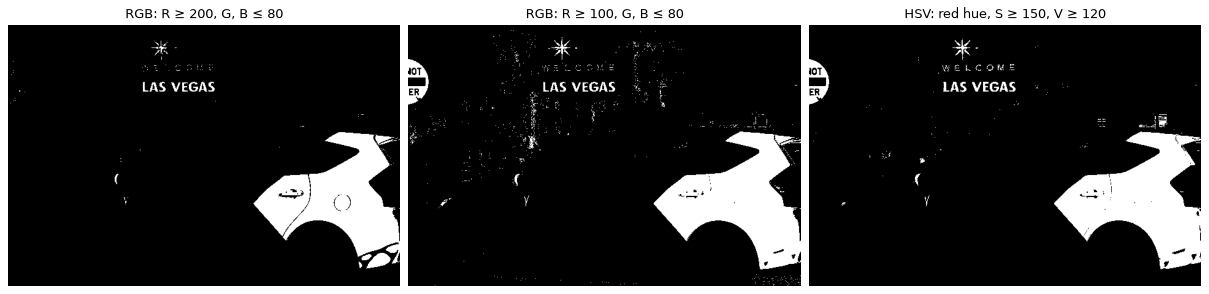

In [13]:
def rgb_red_mask(image_rgb: np.ndarray, min_red: int, max_other: int) -> np.ndarray:
    """Return a uint8 mask of pixels with R >= min_red and G, B <= max_other."""
    r, g, b = cv2.split(image_rgb)
    return ((r >= min_red) & (g <= max_other) & (b <= max_other)).astype(np.uint8) * 255


show_images({
    "RGB: R ≥ 200, G, B ≤ 80": rgb_red_mask(image_rgb, 200, 80),
    "RGB: R ≥ 100, G, B ≤ 80": rgb_red_mask(image_rgb, 100, 80),
    "HSV: red hue, S ≥ 150, V ≥ 120": color_masks["red"],
})

## 8. Split and merge channels

### 8.1 Splitting

`cv2.split` returns the channels as three separate 2D arrays. NumPy indexing (`image[..., 0]`) gives the same result and is faster, because it returns a **view** instead of a copy. Both are shown below.

Why do the channels look gray and not coloured? A single channel is just a 2D array of numbers. Displayed on its own, it is shown as a **grayscale** image, where bright means "a lot of this colour". For example, the blue sky is bright in the blue channel and dark in the red channel, while the red car is the other way round. White areas are bright in all three channels.

Each channel: shape (426, 640), dtype uint8


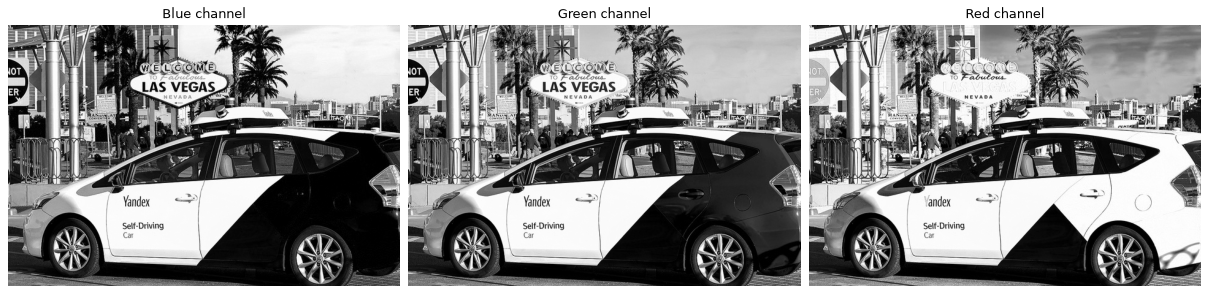

In [14]:
b, g, r = cv2.split(image_bgr)
assert np.array_equal(b, image_bgr[..., 0]), "cv2.split and NumPy indexing should match"
print(f"Each channel: shape {b.shape}, dtype {b.dtype}")

show_images({f"{name} channel": channel
             for name, channel in zip(CHANNEL_NAMES_BGR, (b, g, r))})

### 8.2 Showing a channel in its own colour

To see a channel *in colour*, we build a 3-channel image where the other two channels are zero, e.g. `cv2.merge([B, zeros, zeros])` for blue. `channel_in_color` does this for any channel.

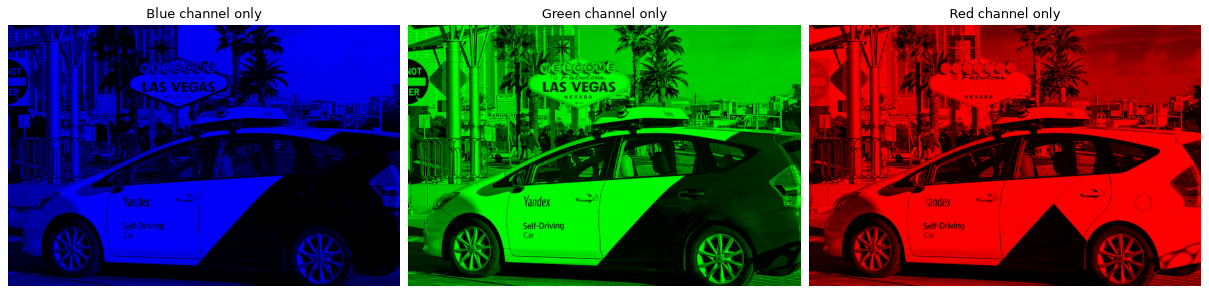

In [15]:
def channel_in_color(image_bgr: np.ndarray, channel: int) -> np.ndarray:
    """Return an RGB image that keeps only one BGR channel (0 = B, 1 = G, 2 = R) and zeros the rest."""
    only = np.zeros_like(image_bgr)
    only[..., channel] = image_bgr[..., channel]
    return cv2.cvtColor(only, cv2.COLOR_BGR2RGB)


show_images({f"{name} channel only": channel_in_color(image_bgr, i)
             for i, name in enumerate(CHANNEL_NAMES_BGR)})

### 8.3 Merging

`cv2.merge` (or `np.dstack`) stacks the channels back into one image. Merging in the original order gives back **exactly** the original image. Merging in a different order swaps colours, which is what the BGR/RGB mix-up in section 5 really is.

Merged == original: True
cv2.merge == np.dstack: True


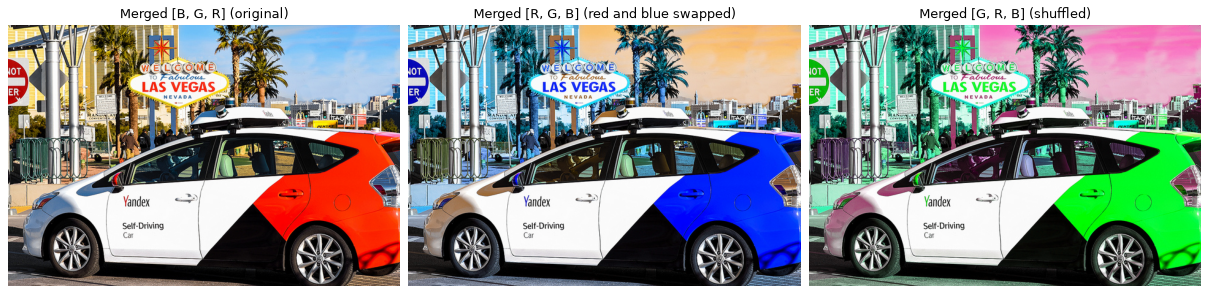

In [16]:
image_merged = cv2.merge([b, g, r])
print(f"Merged == original: {np.array_equal(image_merged, image_bgr)}")
print(f"cv2.merge == np.dstack: {np.array_equal(image_merged, np.dstack([b, g, r]))}")

show_images({
    "Merged [B, G, R] (original)": cv2.cvtColor(image_merged, cv2.COLOR_BGR2RGB),
    "Merged [R, G, B] (red and blue swapped)": cv2.cvtColor(cv2.merge([r, g, b]), cv2.COLOR_BGR2RGB),
    "Merged [G, R, B] (shuffled)": cv2.cvtColor(cv2.merge([g, r, b]), cv2.COLOR_BGR2RGB),
})

## 9. Adding more green, and the uint8 overflow trap

A simple way to make the image greener would be to merge `[B, G + 100, R]`. But the channels are `uint8`, which can only hold 0 – 255. NumPy doesn't clip; it **wraps around** (modulo 256):

$$200 + 100 = 300 \;\rightarrow\; 300 - 256 = 44$$

So the **brightest** green values become **dark**, which creates ugly dark or purple patches in bright areas such as the white car and the sky.

There are several correct ways to do this. `boost_channel` supports two of them:
- `cv2.add`: OpenCV's **saturating** addition, which clips at 255 (the usual choice)
- NumPy: convert to a larger type, add, `np.clip` to 0 – 255, and convert back

The wrapping version is kept only to show the bug.

Green values that overflow with +100: 113,475 of 272,640 (41.6%)
Example pixel (350, 180): G = 252 -> wrap: 96, saturating: 255


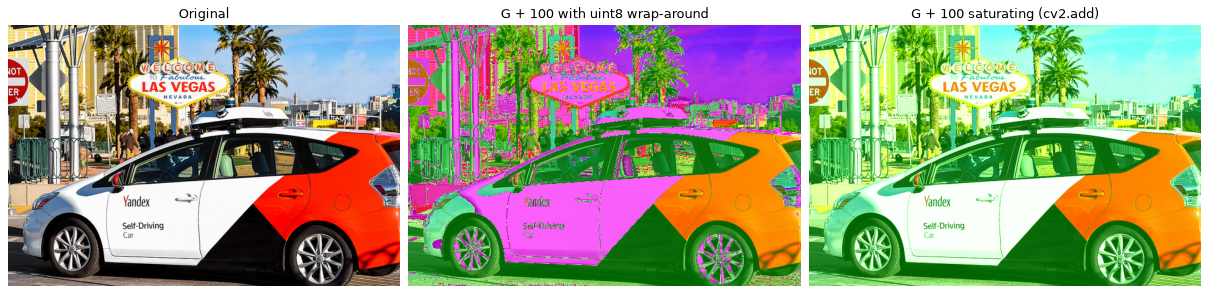

In [17]:
def boost_channel(image_bgr: np.ndarray, channel: int, amount: int, method: str = "cv2") -> np.ndarray:
    """Add `amount` to one BGR channel. method: "cv2" (saturating), "numpy" (clip) or "wrap" (bug)."""
    result = image_bgr.copy()
    if method == "cv2":
        result[..., channel] = cv2.add(image_bgr[..., channel], amount).squeeze()
    elif method == "numpy":
        result[..., channel] = np.clip(image_bgr[..., channel].astype(np.int16) + amount, 0, 255)
    elif method == "wrap":
        result[..., channel] = image_bgr[..., channel] + np.uint8(amount)  # wraps around modulo 256
    else:
        raise ValueError(f"Unknown method: {method!r}")
    return result


GREEN = 1
boost_wrap = boost_channel(image_bgr, GREEN, GREEN_BOOST, method="wrap")
boost_cv2 = boost_channel(image_bgr, GREEN, GREEN_BOOST, method="cv2")
boost_numpy = boost_channel(image_bgr, GREEN, GREEN_BOOST, method="numpy")

assert np.array_equal(boost_cv2, boost_numpy), "cv2.add and np.clip should give the same result"
wrapped = np.count_nonzero(g.astype(int) + GREEN_BOOST > 255)
print(f"Green values that overflow with +{GREEN_BOOST}: {wrapped:,} of {g.size:,} ({wrapped / g.size:.1%})")

row, col = PIXELS["white car door"]
print(f"Example pixel {(row, col)}: G = {g[row, col]} -> wrap: {boost_wrap[row, col, GREEN]}, "
      f"saturating: {boost_cv2[row, col, GREEN]}")

show_images({
    "Original": image_rgb,
    f"G + {GREEN_BOOST} with uint8 wrap-around": cv2.cvtColor(boost_wrap, cv2.COLOR_BGR2RGB),
    f"G + {GREEN_BOOST} saturating (cv2.add)": cv2.cvtColor(boost_cv2, cv2.COLOR_BGR2RGB),
})

In the wrap-around version, the white car, the sign and the sky turn **magenta or purple**: their green values were close to 255 and wrapped around to small numbers. The saturating version gives the expected result: everything turns greener, and white areas simply stay at maximum green.

## 10. Save the results

All results are written to `OUTPUT_DIR`. `save_image` expects a **BGR** or single-channel image, because `cv2.imwrite` assumes BGR. It checks the return value, since `cv2.imwrite` returns `False` instead of raising an error when saving fails.

In [18]:
def save_image(path: Path, image: np.ndarray) -> None:
    """Save a BGR or single-channel image with OpenCV, raising an error if it fails."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if not cv2.imwrite(str(path), image):
        raise OSError(f"Could not write image: {path.resolve()}")
    print(f"Saved {path}")


stem = INPUT_PATH.stem
outputs = {
    "gray": image_gray,
    "hue": image_hsv[..., 0],
    "saturation": image_hsv[..., 1],
    "value": image_hsv[..., 2],
    **{f"channel_{name.lower()}": cv2.cvtColor(channel_in_color(image_bgr, i), cv2.COLOR_RGB2BGR)
       for i, name in enumerate(CHANNEL_NAMES_BGR)},
    **{f"mask_{name}": mask for name, mask in color_masks.items()},
    "green_boost": boost_cv2,
}
for suffix, image in outputs.items():
    save_image(OUTPUT_DIR / f"{stem}_{suffix}.jpg", image)

Saved output/Self_Driving_Car_gray.jpg
Saved output/Self_Driving_Car_hue.jpg
Saved output/Self_Driving_Car_saturation.jpg
Saved output/Self_Driving_Car_value.jpg
Saved output/Self_Driving_Car_channel_blue.jpg
Saved output/Self_Driving_Car_channel_green.jpg
Saved output/Self_Driving_Car_channel_red.jpg
Saved output/Self_Driving_Car_mask_red.jpg
Saved output/Self_Driving_Car_mask_yellow.jpg
Saved output/Self_Driving_Car_mask_green.jpg
Saved output/Self_Driving_Car_mask_blue.jpg
Saved output/Self_Driving_Car_green_boost.jpg


## 11. Conclusion

- **BGR vs. RGB:** OpenCV loads and saves images in BGR, while matplotlib and most other libraries use RGB. Convert once after loading, name variables after their colour space, and colours will never be swapped by accident.
- **Grayscale** reduces the image to one brightness channel with the weights 0.299 R + 0.587 G + 0.114 B. It is cheap and a good input for edge detection, but it throws away all colour information.
- **HSV** separates *which colour* (hue) from *how vivid* (saturation) and *how bright* (value). OpenCV stores hue as 0 – 179 (degrees ÷ 2), and red sits at both ends of the hue axis. Because shadows mostly change only V, HSV colour masks with `cv2.inRange` are much more robust to lighting than RGB thresholds. Section 7.3 showed this on the shaded car body.
- **Split and merge:** a single channel is a 2D array and shows up as grayscale. To view it in colour, zero the other channels. Merging in the original order gives back the exact original image.
- **Watch the data type:** arithmetic on `uint8` wraps around. Use `cv2.add` / `cv2.subtract` or clip in a larger type.
- **Notebook-friendly code:** matplotlib instead of `cv2.imshow`, `pathlib` paths, error checks after `imread` / `imwrite`, and reusable functions instead of copied code.

**Next step for lane detection:** the same `color_mask` function can pick out **yellow** (hue ≈ 15 – 35) and **white** (low saturation, high value) lane markings. Combined with the region-of-interest mask from the previous notebook, this gives a lane mask that works much better in shadows than the RGB and grayscale thresholds used so far.